### Project BackGround
Brain tumors are serious neurological conditions that require early and accurate diagnosis for effective treatment. Magnetic Resonance Imaging (MRI) is widely used for detecting brain abnormalities; however, manual interpretation of MRI scans is time-consuming and may lead to diagnostic errors due to the complexity of medical images. Traditional image processing and machine learning methods often struggle to extract meaningful features from such data.

Convolutional Neural Networks (CNNs) have demonstrated strong performance in medical image analysis by automatically learning features from raw MRI images. This project aims to develop an enhanced CNN-based model for automatic brain tumor detection from MRI images to improve diagnostic accuracy and support healthcare professionals in timely decision-making.

#### Objectives:

- To design and implement a CNN model for classifying MRI images into tumor and non-tumor categories.

- To evaluate the performance of the model using accuracy, precision, recall, and F1-score.



In [1]:
#import libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from PIL import Image
import matplotlib.pyplot as plt
import glob

from imutils import paths
import numpy as np
import matplotlib.pyplot as plt
import argparse
import os
import cv2

### Dataset Details
The dataset used was obtained from kaggle, It had a total of 253 images 98 categorised as non tumor and 155 categorised as tumorous ones which makes it adiquate for model training and evaluation.


brain_tumor_dataset/
├── tumor/
└── no_tumor/

### Data Import And Prepocessing 

Data preprocessing will ivolve steps like:
- resizing of images to achieve consistency in the dataset in terms of shape and size for faster model training and reduction of mismatch errors in the model.
- Intensity Normalization - since MRI images have different brightness and contrast and with variation in pixel intensity, normalization will help to scale pixel values making making model focus on tumor features, improves convergence.
- Skull stripping - Remove any irrelevant non-brain tissues like sculp , eyes,or background which will improve localization accuracy , improve false positive cases.
- Data Augmantation - since MRI data set is small and the images may vary in shape,orientation and size, augmantation will help increasing image size and create variations in existing images, this will prevent overfitting, make model more robust to rotation and scale changes.

In [2]:
#load images from directory file 
path = r"C:\Users\dorice asami\OneDrive\Desktop\Brain_Tumor_Capston\brain_tumor_dataset"
print(os.listdir(path))

image_paths = list(paths.list_images(path))
print(len(image_paths))

['no', 'yes']
253


In [3]:
#Loop over the dataset to extract exact labels as 'yes' or 'no'
#Resize image pixel size
images = []
labels = []

for image_path in image_paths:
    label = image_path.split(os.path.sep)[-2]
    image = cv2.imread(image_path)
    image = cv2.resize(image, (224, 224))

    images.append(image)
    labels.append(label)

#### Convert to Numpy array and Normalize the dataset

In [4]:
#convert to numpy arrays and normalize
images = np.array(images) / 255.0
labels = np.array(labels)

### Encoding
- One hot encoding was used 

In [65]:
#split dataset

lb = LabelBinarizer()
labels = lb.fit_transform(labels)  

labels = to_categorical(labels)  

print(labels[:5])

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


#### Split data into test, train and validation sets

In [27]:
(train_X, test_X, train_Y, test_Y) = train_test_split(
    images, labels,
    test_size=0.10,
    random_state=42,
    stratify=labels
)

In [28]:
(train_x, val_x, train_y, val_y) = train_test_split(
    train_X, train_Y,
    test_size=0.1111,  
    random_state=42,
    stratify=train_Y
)

In [11]:
# convert X to float32
train_X = np.array(train_x).astype("float32")
val_X   = np.array(val_x).astype("float32")
test_X  = np.array(test_X).astype("float32")


In [29]:
print(train_x.shape, val_x.shape, test_Y.shape, train_y.shape, val_y.shape,test_Y.shape)

(201, 224, 224, 3) (26, 224, 224, 3) (26, 2) (201, 2) (26, 2) (26, 2)


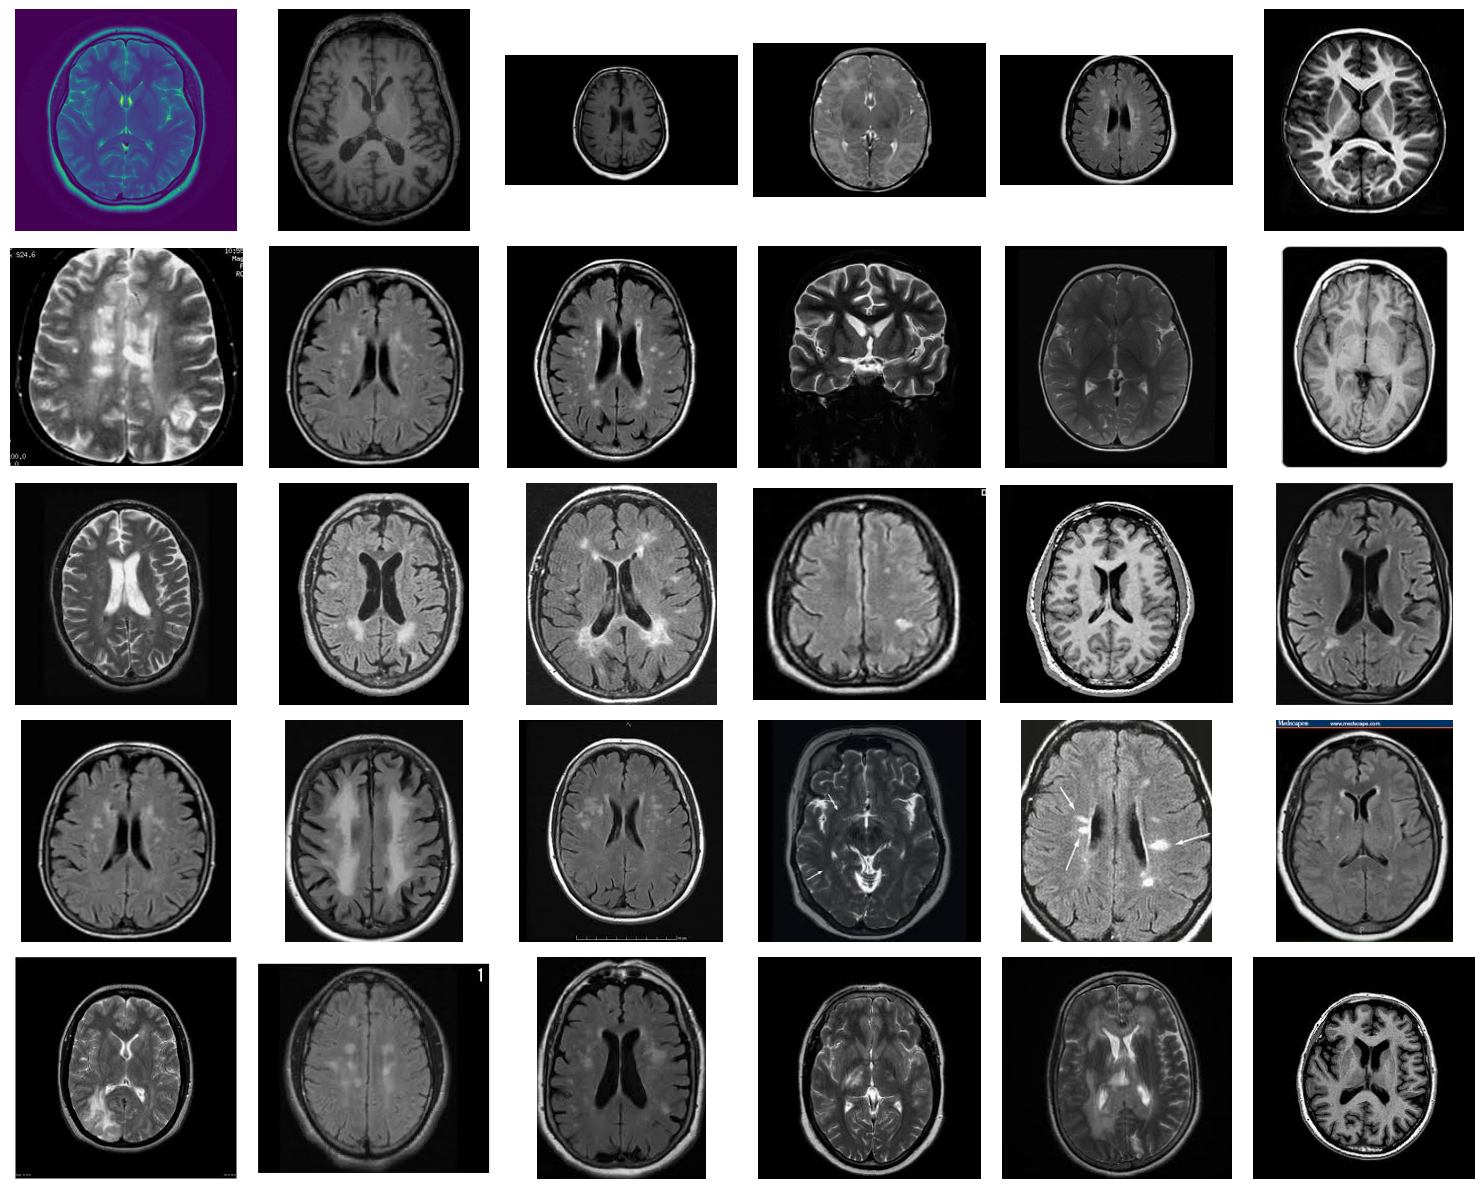

In [ ]:
#Display images
num_images = min(30, len(image_paths))

plt.figure(figsize=(15, 12))
for i, path in enumerate(image_paths[:num_images]):
    img = Image.open(path) 
    plt.subplot(5, 6, i+1)  
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Tumor image with Localization 

(np.float64(-0.5), np.float64(282.5), np.float64(356.5), np.float64(-0.5))

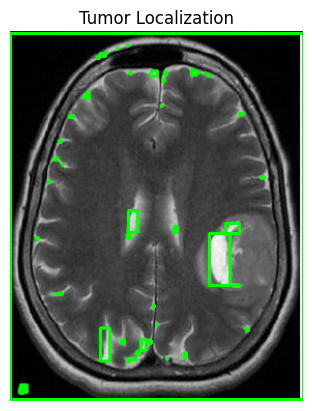

In [26]:
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for c in contours:
    x,y,w,h = cv2.boundingRect(c)
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Tumor Localization")
plt.axis("off")

- The Visual above indicates highlighted tumor areas have been detected through image threshholding and contour techniques.
- Those regions may differ in texture and brightness when compared to a healthy brain tissue.
- Tumor areas vary in shape and size and are mainly concetrated on one side of the brain creating difference in asymmetry


### Augmantation

- Augmantation was performed where images were rotated slighly at -+15, empty pixels created by rotation were filled using nearest values, in each epoch  the model can have slightly different versions of the same image.


In [30]:
# Build the Image Data Generator
train_generator = ImageDataGenerator(fill_mode= 'nearest', rotation_range= 15)

### Model Building and Training
- CNN was the most preffered model for this project since it has sophisticated tools that are well designed for image recognition and processing tasks. CNN has a powerful framework for generative and descriptive image analysis tasks.
- Due to dataset size we only had 257 images, building a CNN model from scartch was a challenge since the model had high chances of memorizing instead of learning, It was therefore prefferable to use VGG16 model directly since its know to have already learned from a variety of image features.

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [44]:
# Build the model
base_model = VGG16(weights= 'imagenet', input_tensor= Input(shape = (224, 224, 3)), include_top= False)
base_input = base_model.input
base_output = base_model.output
base_output = AveragePooling2D(pool_size=(4, 4))(base_output)
base_output = Flatten(name="flatten")(base_output)
base_output = Dense(64, activation="relu")(base_output)
base_output = Dropout(0.5)(base_output)
base_output = Dense(2, activation="softmax")(base_output)

In [45]:
# Freeze the layers
for layer in base_model.layers:
    layer.trainable = False

In [46]:
# Compile the model
model = Model(inputs = base_input, outputs = base_output)
model.compile(optimizer= Adam(learning_rate= 1e-3), metrics= ['accuracy'], loss= 'binary_crossentropy')

In [47]:
#view model summary
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 1, 512)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 14,747,650 (56.26 MB)

 Trainable params: 32,962 (128.76 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [49]:
#Train the model
batch_size = 8
train_steps = len(train_X) // batch_size
validation_steps = len(test_X) // batch_size
epochs = 10

In [52]:
# Fit the model
history = model.fit(train_generator.flow(train_x, train_y, batch_size= batch_size),
                              steps_per_epoch= train_steps,
                              validation_data = (val_x, val_y),
                              validation_steps= validation_steps,
                              epochs= epochs)

Epoch 1/10
26/28 ━━━━━━━━━━━━━━━━━━━━ 1s 894ms/step - accuracy: 0.7966 - loss: 0.5190

c:\Users\dorice asami\OneDrive\Desktop\Brain_Tumor_Capston\tumor\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 958ms/step - accuracy: 0.7463 - loss: 0.5393 - val_accuracy: 0.9615 - val_loss: 0.5137
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 948ms/step - accuracy: 0.7214 - loss: 0.5457 - val_accuracy: 0.8846 - val_loss: 0.4959
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.7612 - loss: 0.4990 - val_accuracy: 0.8846 - val_loss: 0.4884
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7711 - loss: 0.4945 - val_accuracy: 0.8846 - val_loss: 0.4855
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7761 - loss: 0.5064 - val_accuracy: 0.8462 - val_loss: 0.4673
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7711 - loss: 0.4840 - val_accuracy: 0.6538 - val_loss: 0.5397
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8010 - loss: 0.4791 - val_accuracy: 0.8846 - val_loss: 0.4482
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7861 - loss: 0.4564 - val_accuracy: 0.8462 - val_loss: 0.45

- From above train accuracy is at 0.8 while validatition accuracy bounces at arounf 0.65 to 0.96 giving a validation loss of 0.44
- This means validation set might have been too small or augmentation negagively affected the results

#### Evaluate the Model

In [56]:
# VGG16 model performance
loss, accuracy = model.evaluate(val_x, val_y, verbose=0)

print(f"\nFinal Test Loss: {loss:.4f}")
print(f"Final Test Accuracy: {accuracy:.4f}")


Final Test Loss: 0.4364
Final Test Accuracy: 0.8846


In [62]:
# Evaluate the model
predictions = model.predict(test_X, batch_size= batch_size)
predictions = np.argmax(predictions, axis= 1)
actuals = np.argmax(test_Y, axis= 1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 492ms/step


### Confusion matrix
From above it was notable that model dint perform well on the validation set, this may be due to missclafications, a confusion matrix will help visualize if we have any.

In [57]:
from sklearn.metrics import confusion_matrix, classification_report

In [67]:

#Print Classification report and Confusion matrix

print(classification_report(actuals, predictions, target_names= lb.classes_))

cm = confusion_matrix(actuals, predictions)
print(cm)

              precision    recall  f1-score   support

          no       0.91      1.00      0.95        10
         yes       1.00      0.94      0.97        16

    accuracy                           0.96        26
   macro avg       0.95      0.97      0.96        26
weighted avg       0.97      0.96      0.96        26

[[10  0]
 [ 1 15]]


- accuracy is at 96% , F1 score is 0.96 indicating that performance is high accross ll classes
- From above no none tumor images were misclassified, 1 out of 16 tumor images was misclassified, generally model shows strong tumor detection.



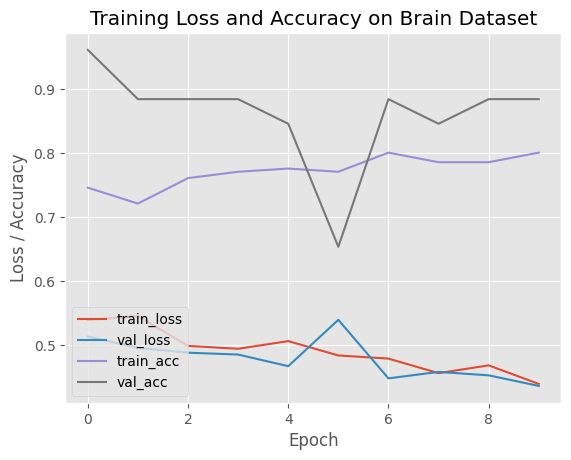

In [68]:
# Plot the losses and accuracies
N = epochs
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, N), history.history["loss"], label= "train_loss")
plt.plot(np.arange(0, N), history.history["val_loss"], label= "val_loss")

plt.plot(np.arange(0, N), history.history["accuracy"], label= "train_acc")
plt.plot(np.arange(0, N), history.history["val_accuracy"], label= "val_acc")

plt.title("Training Loss and Accuracy on Brain Dataset")
plt.xlabel("Epoch")
plt.ylabel("Loss / Accuracy")
plt.legend(loc= "lower left")
plt.savefig("plot.jpg")

- From visual above raining curves show steady convergence with decreasing loss and increasing accuracy. Validation performance remains high throughout training, with minor fluctuations due to the small dataset size. No significant overfitting is observed, indicating good generalization of the VGG16-based model.